# E205 Lab 1: Data Manipulation & Modeling
**Author:** Viviane Solomon  
**Course:** E205 (State Estimation), Harvey Mudd College

## 0. Setup
Mount Google Drive and import libraries.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Load Data

LiDAR data collected from a stationary sensor in the Parsons building courtyard.
Three CSV files correspond to azimuth angles of -90°, 0°, and 90°.

In [2]:
BASE = '/content/drive/MyDrive/E205_Lab_01_data.zip (Unzipped Files)/'

df_azneg = pd.read_csv(BASE + 'lab1_azimuth_-90.csv')
df_azzero = pd.read_csv(BASE + 'lab1_azimuth_00.csv')
df_azpos  = pd.read_csv(BASE + 'lab1_azimuth_90.csv')

#Extract range vectors used throughout the notebook
range_neg90 = df_azneg['Range(m)']
range_zero  = df_azzero['Range(m)']
range_pos90 = df_azpos['Range(m)']

print(f"Loaded: {len(range_neg90)} , {len(range_zero)} , and {len(range_pos90)} samples (az -90 , 0 , +90, respectfully)")


Loaded: 1140 , 1138 , and 1164 samples (az -90 , 0 , +90, respectfully)


## 2. Range Histograms

Plot empirical distribution of range measurements for each azimuth angle.

Each histogram approximates the likelihood function `p(z | x)` for that direction.

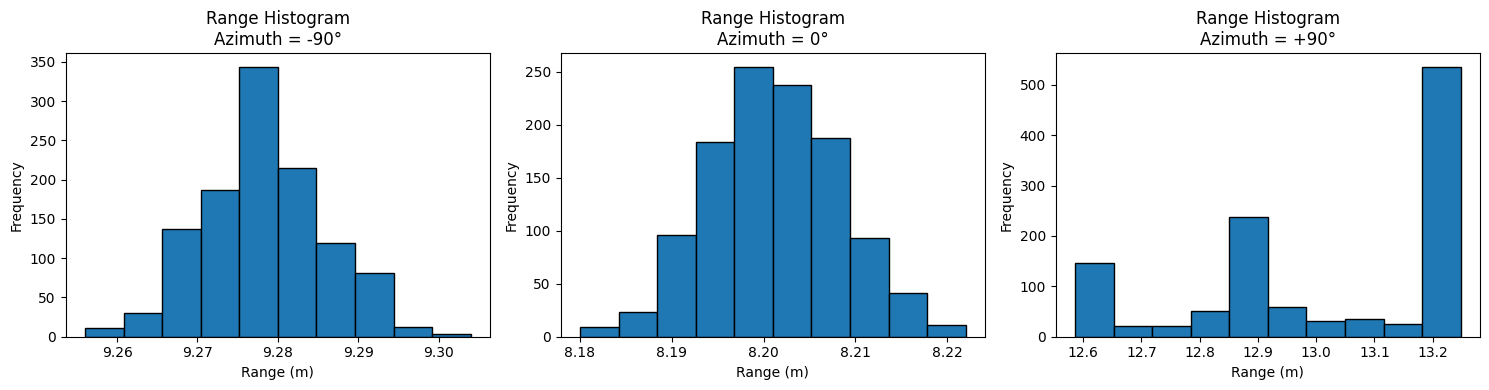

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

configs = [
    (range_neg90, 'Azimuth = -90°'),
    (range_zero,  'Azimuth = 0°'),
    (range_pos90, 'Azimuth = +90°'),
]

for ax, (data, title) in zip(axes, configs):
    ax.hist(data, bins=10, edgecolor='black')
    ax.set_title(f'Range Histogram\n{title}')
    ax.set_xlabel('Range (m)')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()


## 3. Gaussian Sensor Model

Model the sensor likelihood as a Gaussian:

$$p(z \mid \mu, \sigma^2) = \frac{1}{\sigma\sqrt{2\pi}} \exp\!\left(-\frac{(z-\mu)^2}{2\sigma^2}\right)$$

Parameters `μ` and `σ` are estimated from the azimuth = -90° data using the sample mean and standard deviation.

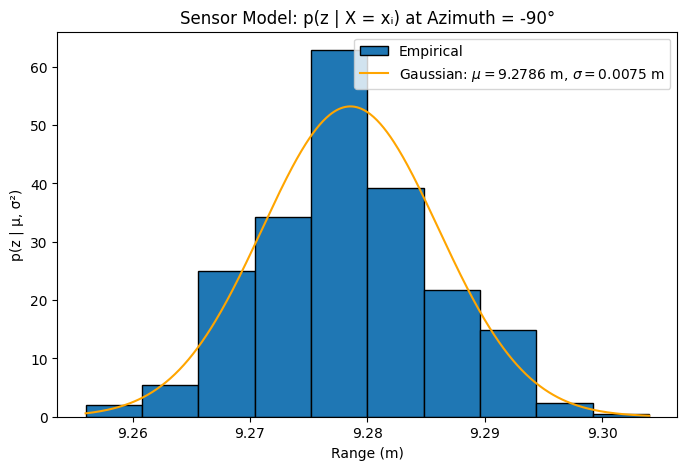

μ = 9.2786 m
σ = 0.0075 m


In [6]:
#Fit Gaussian to azimuth = -90° range data
mu    = range_neg90.mean()
sigma = range_neg90.std(ddof=1)   #ddof=1 -> unbiased sample std

def gaussian(z, mu=mu, sigma=sigma):
    """Gaussian PDF evaluated at z, defaulting to the fitted sensor model."""
    return (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((z - mu) / sigma) ** 2)

#Plot histogram vs fitted model
z_grid = np.linspace(range_neg90.min(), range_neg90.max(), 500)

plt.figure(figsize=(8, 5))
plt.hist(range_neg90, bins=10, density=True, edgecolor='black', label='Empirical')
plt.plot(z_grid, gaussian(z_grid), color='orange',
         label=fr'Gaussian: $\mu={mu:.4f}$ m, $\sigma={sigma:.4f}$ m')
plt.xlabel('Range (m)')
plt.ylabel('p(z | μ, σ²)')
plt.title('Sensor Model: p(z | X = xᵢ) at Azimuth = -90°')
plt.legend()
plt.show()

print(f"μ = {mu:.4f} m")
print(f"σ = {sigma:.4f} m")


## 4. GPS Coordinate Transform

Convert raw latitude/longitude from the azimuth = 0° file into local X/Y coordinates (meters)
using the flat-earth approximation from E80 Lab 7:

$$x = R_{\text{earth}} \cdot \Delta\lambda \cdot \cos(\phi_0), \quad y = R_{\text{earth}} \cdot \Delta\phi$$

where $\phi_0$ and $\lambda_0$ are the mean lat/lon (the origin).

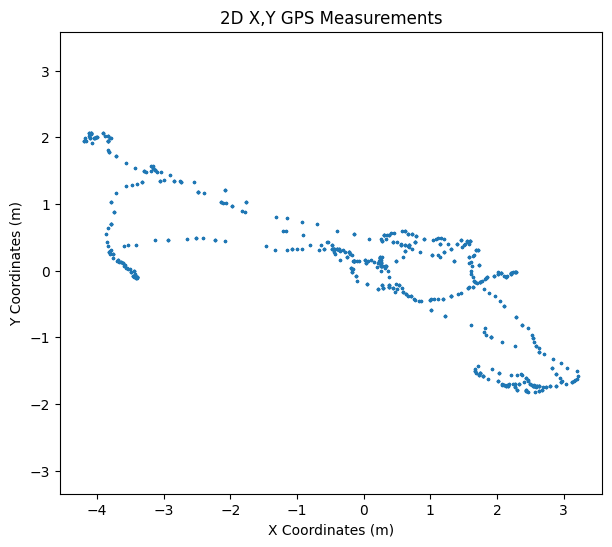

X std: 2.2230 m  |  Y std: 1.0011 m
The X-coordinate has larger spread (higher variance) than Y.


In [8]:
R_EARTH = 6335439  #meters

#Convert to radians
lat_rad = df_azzero['Latitude']  * (np.pi / 180)
lon_rad = df_azzero['Longitude'] * (np.pi / 180)

#Define origin as mean position
lat0 = lat_rad.mean()
lon0 = lon_rad.mean()

#Flat-earth transform
x = R_EARTH * (lon_rad - lon0) * np.cos(lat0)
y = R_EARTH * (lat_rad - lat0)

plt.figure(figsize=(7, 6))
plt.plot(x, y, '.', markersize=3)
plt.title('2D X,Y GPS Measurements')
plt.xlabel('X Coordinates (m)')
plt.ylabel('Y Coordinates (m)')
plt.axis('equal')
plt.show()

print(f"X std: {np.std(x):.4f} m  |  Y std: {np.std(y):.4f} m")
print("The X-coordinate has larger spread (higher variance) than Y.")


## 5. Bayes Rule – Discrete State Estimation

We assume the sensor can be in one of 4 discrete positions:

| State | xᵢ (m) | yᵢ (m) | μᵢ = 11 + xᵢ (m) |
|-------|---------|---------|------------------|
| x₁   | -1.70   | 2.8     | 9.30             |
| x₂   | -1.72   | 2.8     | 9.28             |
| x₃   | -1.74   | 2.8     | 9.26             |
| x₄   | -1.76   | 2.8     | 9.24             |

Equal prior: `p(xᵢ) = 0.25` for all states.

Using Bayes rule:
$$p(x_i \mid z) = \eta \cdot p(z \mid x_i) \cdot p(x_i)$$

In [10]:
z_meas   = 9.272                              #single range measurement (m)
x_states = np.array([-1.70, -1.72, -1.74, -1.76])
mu_xi    = 11.0 + x_states                   #expected range per state
prior    = 0.25                               #uniform prior over 4 states

#Table 1: likelihood p(z | xᵢ) using fitted Gaussian model
p_z_given_xi = gaussian(z_meas, mu=mu_xi, sigma=sigma)

#Table 2: unnormalized posterior  p̄(xᵢ | z) = p(z|xᵢ) · p(xᵢ)
pbar = prior * p_z_given_xi

#Normalization factor η and Table 3: normalized posterior
eta          = 1.0 / np.sum(pbar)
p_xi_given_z = eta * pbar

#Print results
print("Table 1 – p(z | xᵢ):    ", np.round(p_z_given_xi, 4))
print("Table 2 – p̄(xᵢ | z):    ", np.round(pbar,         4))
print(f"η = {eta:.4f}")
print("Table 3 – p(xᵢ | z):    ", np.round(p_xi_given_z, 6))
print(f"Sanity check – sum = {np.sum(p_xi_given_z):.6f}")


Table 1 – p(z | xᵢ):     [4.99000e-02 3.01141e+01 1.47842e+01 5.90000e-03]
Table 2 – p̄(xᵢ | z):     [1.2500e-02 7.5285e+00 3.6961e+00 1.5000e-03]
η = 0.0890
Table 3 – p(xᵢ | z):     [1.11000e-03 6.69885e-01 3.28874e-01 1.31000e-04]
Sanity check – sum = 1.000000


## 6. Police Data Model – p(Victim's Age | Victim's Race)

Using the `police_killings.csv` dataset. We model the conditional distribution of victim age
given race using two methods:

- **Method a** – Gaussian PDF fit (μ, σ from data)
- **Method b** – Empirical histogram (actual age distribution)

Method a is more principled probabilistically; method b is more faithful to the raw data.

In [11]:
# Load and clean
pk = pd.read_csv('/content/drive/MyDrive/police_killings.csv')
pk = pk[["Victim's age", "Victim's race"]].copy()
pk["Victim's age"] = pd.to_numeric(pk["Victim's age"], errors='coerce')
pk = pk.dropna(subset=["Victim's age", "Victim's race"])
pk = pk[pk["Victim's age"] >= 0]

# Normalize race labels to lowercase for consistent matching
pk["Victim's race"] = pk["Victim's race"].str.strip().str.lower()

RACES = ['black', 'white', 'hispanic', 'asian']

print("Sample counts per race:")
print(pk["Victim's race"].value_counts())


Sample counts per race:
Victim's race
white               3355
black               1925
hispanic            1297
unknown race         612
asian                118
native american      108
pacific islander      42
Name: count, dtype: int64


### Method a – Gaussian PDF Fit

Fit a Gaussian to the continuous age values for each racial group.

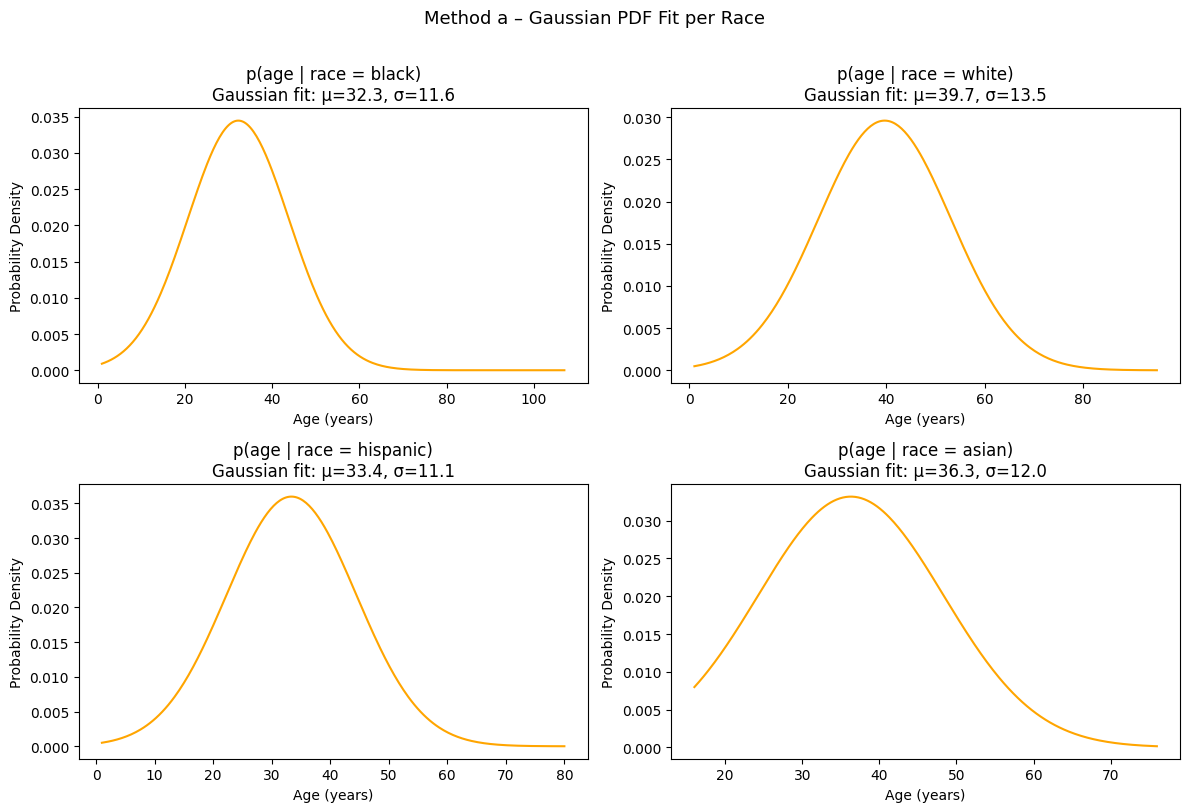

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, race in zip(axes, RACES):
    ages = pk[pk["Victim's race"] == race]["Victim's age"]
    if len(ages) < 2:
        ax.set_visible(False)
        continue

    mu_r    = ages.mean()
    sigma_r = ages.std(ddof=1)
    z_grid  = np.linspace(ages.min(), ages.max(), 300)
    pdf     = gaussian(z_grid, mu=mu_r, sigma=sigma_r)

    ax.plot(z_grid, pdf, color='orange')
    ax.set_title(f"p(age | race = {race})\nGaussian fit: μ={mu_r:.1f}, σ={sigma_r:.1f}")
    ax.set_xlabel("Age (years)")
    ax.set_ylabel("Probability Density")

plt.suptitle("Method a – Gaussian PDF Fit per Race", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


### Method b – Empirical Histogram

Plot the normalized histogram of actual ages for each racial group.

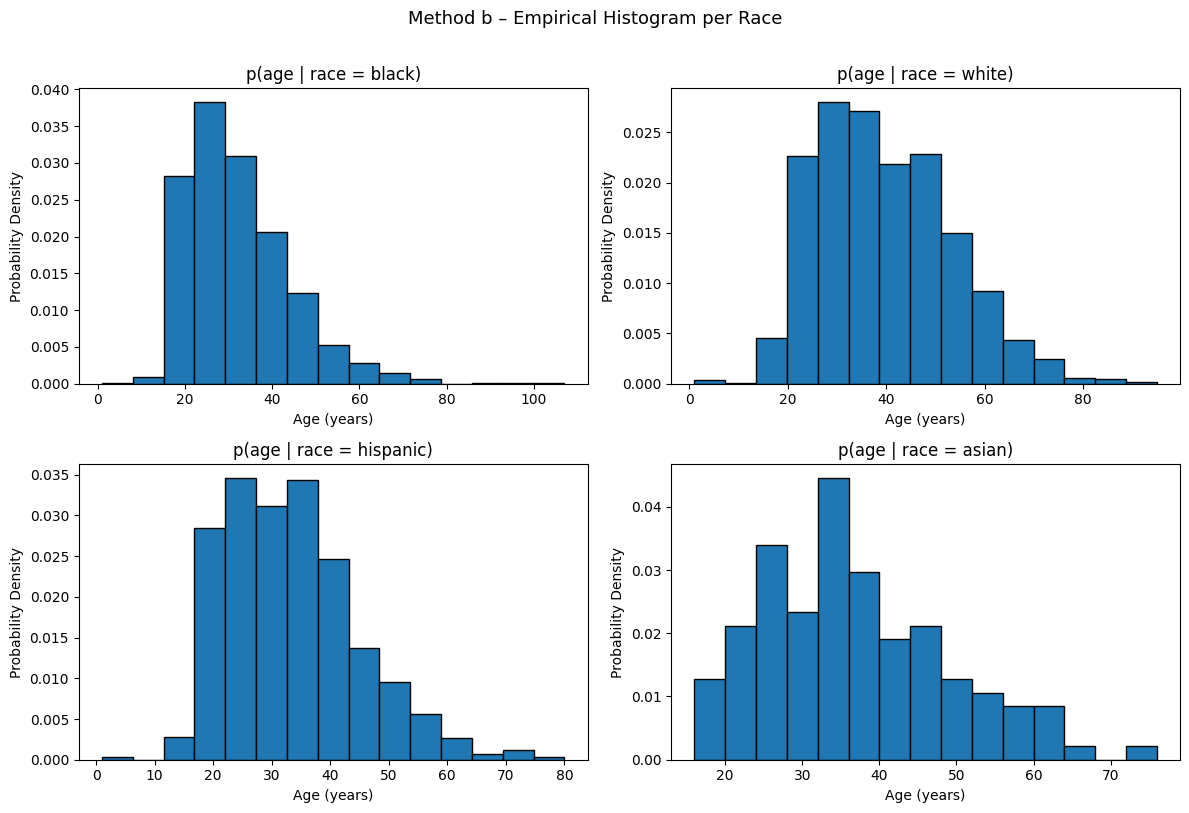

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, race in zip(axes, RACES):
    ages = pk[pk["Victim's race"] == race]["Victim's age"]
    if len(ages) == 0:
        ax.set_visible(False)
        continue

    ax.hist(ages, bins=15, density=True, edgecolor='black')
    ax.set_title(f"p(age | race = {race})")
    ax.set_xlabel("Age (years)")
    ax.set_ylabel("Probability Density")

plt.suptitle("Method b – Empirical Histogram per Race", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()
